<a href="https://colab.research.google.com/github/alex-jk/YRP-vehicle-accidents/blob/main/yrp_vehicle_accidents_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import YRP data**

In [102]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Colab starts in an empty cloud VM, so clone the (public) repo in.
    if not os.path.isdir('YRP-vehicle-accidents'):
        !git clone https://github.com/alex-jk/YRP-vehicle-accidents.git
    %cd YRP-vehicle-accidents
else:
    # Running locally (VS Code, Jupyter, etc.) — already inside the repo, nothing to clone.
    print("Running locally, skipping clone.")

Running locally, skipping clone.


In [103]:
import pandas as pd
import re
import matplotlib.pyplot as plt
df = pd.read_csv("data/YRP Data vehicle accidents 2023 - now.csv")

# Parse year
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

# People per row: count items in Age/Gender (comma- or slash-separated); use max; default to 1
def count_items(x):
    if not isinstance(x, str): return 0
    parts = [p.strip() for p in re.split(r'[,/]', x) if p.strip()]
    return len(parts)

age_n    = df['Age'].apply(count_items)
gender_n = df['Gender'].apply(count_items)
person_n = age_n.combine(gender_n, max).where(lambda s: s>0, 1)
# print(person_n)

# Robust Y/N → boolean
is_yes = lambda x: isinstance(x, str) and x.strip().upper().startswith('Y')
mot = df['Motorcycle'].map(is_yes)
ped = df['Pedestrian'].map(is_yes)
cyc = df['Cyclist'].map(is_yes)
mob = df['Mobility Scooter'].map(is_yes)

# Category per row (priority: Pedestrian > Cyclist > Mobility scooter > Other)
def victim_type(mot, ped, cyc, mob):
    if mot: return 'Motorcyclist'
    if ped: return 'Pedestrian'
    if cyc: return 'Cyclist'
    if mob: return 'Mobility Scooter'
    return 'Car'

df['Type'] = [victim_type(m, p, c, b) for m, p, c, b in zip(mot, ped, cyc, mob)]
df['Deaths'] = person_n

print(f"\nDF shape: {df.shape}")
df.head(10)


DF shape: (88, 18)


,ID,Date,Time,Main Street,Main Street 2,Municipality,Intersection,Motorcycle,Age,Gender,Mobility Scooter,Pedestrian,Single Vehicle,Night,Cyclist,Year,Type,Deaths
0,2023_16704,2023-01-14,14:28,McCowan Road,Bur Oak Avenue,Markham,Y,N,75,Female,N,N,N,N,N,2023,Car,1
1,2023_35339,2023-01-30,6:30,9th Line,Bloomington Road,Whitchurch-Stouffville,Y,N,"Adult, Adult","Male, Male",N,N,N,N,N,2023,Car,2
2,2023_87652,2023-03-15,12:49,Highway 48,NaN,Whitchurch-Stouffville,N,N,35,Male,N,Y,N,N,N,2023,Pedestrian,1
3,2023_170962,2023-05-19,23:49,Major MacKenzie Dr W,Jane Street,Vaughan,Y,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,2023,Pedestrian,1
4,2023_175551,2023-05-23,18:11,Pine Valley Drive,Major MacKenzie Dr W,Vaughan,Y,N,20,Male,N,Y,N,N,N,2023,Pedestrian,1
5,2023_183025,2023-05-29,7:52,Jane Street,NaN,King,Y,Y,Adult,Male,N,N,N,N,N,2023,Motorcyclist,1
6,2023_189685,2023-06-01,19:21,Pine Valley Drive,NaN,Vaughan,N,N,72,Female,N,N,N,N,N,2023,Car,1
7,2023_238781,2023-07-05,12:22,Dudley Avenue,NaN,Markham,N,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,2023,Pedestrian,1
8,2023_265277,2023-07-25,22:15,Highway 7,Thornhill Woods Drive,Vaughan,Y,Y,"45, 47","Male, Female",N,N,N,N,N,2023,Motorcyclist,2
9,2023_269592,2023-07-29,10:23,Keele Street,Sherwood Park Dr,Vaughan,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,Car,1


**Summarize by year and type**

In [104]:
# Sum people by year & type
counts = (
    df.groupby(['Year','Type'])['Deaths']
      .sum()
      .unstack('Type')
      .fillna(0)
      .astype(int)
      .sort_index()
)

# totals (people) per year
year_totals = df.groupby('Year')['Deaths'].sum()

def gender_counts(cell, deaths):
    # NA/blank → all Unknown
    if not isinstance(cell, str) or not cell.strip():
        return pd.Series({'Male Total': 0, 'Female Total': 0, 'Unknown Total': deaths})
    toks = [t.strip().lower() for t in re.split(r'[,/;|]', cell) if t.strip()]
    m = sum(t.startswith('m') for t in toks)        # M / Male
    f = sum(t.startswith('f') for t in toks)        # F / Female
    other = sum(not (t.startswith('m') or t.startswith('f')) for t in toks)
    u = other + max(0, deaths - (m + f + other))    # any extra people → Unknown
    return pd.Series({'Male Total': m, 'Female Total': f, 'Unknown Total': u})

# row → year totals
totals_cols = ['Male Total','Female Total','Unknown Total']
by_year_gender = (
    pd.concat([df['Year'],
               df.apply(lambda r: gender_counts(r['Gender'], int(r['Deaths'])), axis=1)], axis=1)
      .groupby('Year')[totals_cols].sum()
)

# Make the table tidy, ordered, with totals
nice = counts.copy()

# attach to counts table
for col in ['Male Total','Female Total','Unknown Total']:
    nice[col] = by_year_gender.reindex(nice.index.drop('All years', errors='ignore')).get(col)

# "All years" totals
nice.loc['All years', totals_cols] = by_year_gender.sum().values

# ensure all expected columns exist
select_cols = ['Motorcyclist', 'Pedestrian', 'Cyclist', 'Mobility Scooter', 'Car']
all_cols = select_cols + totals_cols
for col in all_cols:
    if col not in nice.columns:
        nice[col] = 0

# order columns and add totals
nice = nice[all_cols]
nice['Total'] = nice[select_cols].sum(axis=1)

count_cols = select_cols + totals_cols + ['Total']
nice.loc['All years', count_cols] = (
    nice.drop(index='All years', errors='ignore')[count_cols].sum()
)
# ints + a simple style (optional in notebooks)
nice = nice.astype(int)

# pct columns per row
den = (nice[totals_cols].sum(axis=1)).replace(0, pd.NA)
nice['Male %']    = (nice['Male Total']    / den * 100).round(1)
nice['Female %']  = (nice['Female Total']  / den * 100).round(1)
nice['Unknown %'] = (100 - nice['Male %'] - nice['Female %']).round(1)

nice.style.set_caption("Fatalities by Year and Victim Type") \
          .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold')]}]) \
          .format('{:,}')

Type,Motorcyclist,Pedestrian,Cyclist,Mobility Scooter,Car,Male Total,Female Total,Unknown Total,Total,Male %,Female %,Unknown %
Year,,,,,,,,,,,,
2023,5,9,0,0,9,11,7,5,23,47.8,30.4,21.8
2024,5,8,1,1,13,22,5,1,28,78.6,17.9,3.5
2025,3,10,1,0,16,17,6,7,30,56.7,20.0,23.3
2026,4,1,0,0,4,4,3,2,9,44.4,33.3,22.3
All years,17,28,2,1,42,54,21,15,90,60.0,23.3,16.7


In [105]:
# Simplified Year x Type table (Reddit post format): just the type counts + Year Total,
# reusing the `nice` table built above.
year_type_table = nice[['Car', 'Motorcyclist', 'Pedestrian', 'Cyclist', 'Mobility Scooter', 'Total']].copy()
year_type_table = year_type_table.rename(columns={'Total': 'Year Total'})
year_type_table = year_type_table.rename(index={'All years': 'Total'})

# Print as markdown -- copy/paste this straight into Reddit's markdown editor
# (switch the comment box to "Markdown Editor" mode via the toggle at the bottom left,
# it won't render as a table in the default Fancy Pants editor).
print(year_type_table.to_markdown())
year_type_table

| Year   |   Car |   Motorcyclist |   Pedestrian |   Cyclist |   Mobility Scooter |   Year Total |
|:-------|------:|---------------:|-------------:|----------:|-------------------:|-------------:|
| 2023   |     9 |              5 |            9 |         0 |                  0 |           23 |
| 2024   |    13 |              5 |            8 |         1 |                  1 |           28 |
| 2025   |    16 |              3 |           10 |         1 |                  0 |           30 |
| 2026   |     4 |              4 |            1 |         0 |                  0 |            9 |
| Total  |    42 |             17 |           28 |         2 |                  1 |           90 |


Type,Car,Motorcyclist,Pedestrian,Cyclist,Mobility Scooter,Year Total
Year,,,,,,
2023,9,5,9,0,0,23
2024,13,5,8,1,1,28
2025,16,3,10,1,0,30
2026,4,4,1,0,0,9
Total,42,17,28,2,1,90


In [106]:
# Gender by Year table (Reddit post format), reusing the `nice` table built above.
gender_year_table = nice[['Male Total', 'Female Total', 'Unknown Total', 'Male %', 'Female %', 'Unknown %']].copy()
gender_year_table = gender_year_table.rename(columns={
    'Male Total': 'Male', 'Female Total': 'Female', 'Unknown Total': 'Unknown'
})
gender_year_table = gender_year_table.rename(index={'All years': 'Total'})
gender_year_table[['Male', 'Female', 'Unknown']] = gender_year_table[['Male', 'Female', 'Unknown']].astype(int)
for col in ['Male %', 'Female %', 'Unknown %']:
    gender_year_table[col] = gender_year_table[col].map(lambda x: f"{x:.1f}%")

print(gender_year_table.to_markdown())
gender_year_table

| Year   |   Male |   Female |   Unknown | Male %   | Female %   | Unknown %   |
|:-------|-------:|---------:|----------:|:---------|:-----------|:------------|
| 2023   |     11 |        7 |         5 | 47.8%    | 30.4%      | 21.8%       |
| 2024   |     22 |        5 |         1 | 78.6%    | 17.9%      | 3.5%        |
| 2025   |     17 |        6 |         7 | 56.7%    | 20.0%      | 23.3%       |
| 2026   |      4 |        3 |         2 | 44.4%    | 33.3%      | 22.3%       |
| Total  |     54 |       21 |        15 | 60.0%    | 23.3%      | 16.7%       |


Type,Male,Female,Unknown,Male %,Female %,Unknown %
Year,,,,,,
2023,11,7,5,47.8%,30.4%,21.8%
2024,22,5,1,78.6%,17.9%,3.5%
2025,17,6,7,56.7%,20.0%,23.3%
2026,4,3,2,44.4%,33.3%,22.3%
Total,54,21,15,60.0%,23.3%,16.7%


**Summary by gender and type**

In [107]:
by_type_gender = (
    pd.concat([df['Type'],
               df.apply(lambda r: gender_counts(r['Gender'], int(r['Deaths'])), axis=1)], axis=1)
      .groupby('Type')[totals_cols].sum()
).reindex(select_cols, fill_value=0)

# add totals and percents
by_type_gender['Total'] = by_type_gender[totals_cols].sum(axis=1)
percent_cols = [c.replace('Total', '%') for c in totals_cols]
for tcol, pcol in zip(totals_cols, percent_cols):
    by_type_gender[pcol] = (by_type_gender[tcol] / by_type_gender['Total'] * 100).round(1)

# tidy order
ordered_cols = totals_cols + ['Total'] + percent_cols
tbl_disp = by_type_gender[ordered_cols].copy()
tbl_disp[totals_cols + ['Total']] = tbl_disp[totals_cols + ['Total']].astype(int)

# nice display
tbl_disp.style.set_caption("By Type — Gender Totals and %") \
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight','bold')]}]) \
    .format({**{c: '{:,}' for c in totals_cols + ['Total']},
             **{c: '{:.1f}%' for c in percent_cols}})

,Male Total,Female Total,Unknown Total,Total,Male %,Female %,Unknown %
Type,,,,,,,
Motorcyclist,14,2,1,17,82.4%,11.8%,5.9%
Pedestrian,18,7,3,28,64.3%,25.0%,10.7%
Cyclist,2,0,0,2,100.0%,0.0%,0.0%
Mobility Scooter,1,0,0,1,100.0%,0.0%,0.0%
Car,19,12,11,42,45.2%,28.6%,26.2%


In [108]:
# By Type gender table (Reddit post format), reusing `tbl_disp` built above.
gender_type_table = tbl_disp[['Male Total', 'Female Total', 'Unknown Total', 'Male %', 'Female %', 'Unknown %']].copy()
gender_type_table = gender_type_table.rename(columns={'Unknown Total': 'Unknown'})
gender_type_table = gender_type_table.reindex(['Car', 'Pedestrian', 'Motorcyclist', 'Cyclist', 'Mobility Scooter'])
gender_type_table.index.name = 'Type'
for col in ['Male %', 'Female %', 'Unknown %']:
    gender_type_table[col] = gender_type_table[col].map(lambda x: f"{x:.1f}%")

print(gender_type_table.to_markdown())
gender_type_table

| Type             |   Male Total |   Female Total |   Unknown | Male %   | Female %   | Unknown %   |
|:-----------------|-------------:|---------------:|----------:|:---------|:-----------|:------------|
| Car              |           19 |             12 |        11 | 45.2%    | 28.6%      | 26.2%       |
| Pedestrian       |           18 |              7 |         3 | 64.3%    | 25.0%      | 10.7%       |
| Motorcyclist     |           14 |              2 |         1 | 82.4%    | 11.8%      | 5.9%        |
| Cyclist          |            2 |              0 |         0 | 100.0%   | 0.0%       | 0.0%        |
| Mobility Scooter |            1 |              0 |         0 | 100.0%   | 0.0%       | 0.0%        |


,Male Total,Female Total,Unknown,Male %,Female %,Unknown %
Type,,,,,,
Car,19,12,11,45.2%,28.6%,26.2%
Pedestrian,18,7,3,64.3%,25.0%,10.7%
Motorcyclist,14,2,1,82.4%,11.8%,5.9%
Cyclist,2,0,0,100.0%,0.0%,0.0%
Mobility Scooter,1,0,0,100.0%,0.0%,0.0%


**Summary by age group and type**

In [109]:
def age_bucket_counts(cell, deaths):
    out = {'Under 20': 0, 'Adult': 0, '60+': 0, 'Age Unknown': 0}
    if not isinstance(cell, str) or not cell.strip():
        out['Age Unknown'] = deaths; return pd.Series(out)
    toks = [t.strip() for t in re.split(r'[,/;|]', cell) if t.strip()]
    for t in toks:
        tl = t.lower()
        if tl == 'adult': out['Adult'] += 1
        elif tl == 'youth': out['Under 20'] += 1
        elif tl in {'na','n/a','unknown'}: out['Age Unknown'] += 1
        elif tl == '60+': out['60+'] += 1
        else:
            digits = re.sub(r'[^\d]', '', tl)
            if digits:
                n = int(digits)
                out['60+' if n>=60 else 'Adult' if n>=20 else 'Under 20'] += 1
            else:
                out['Age Unknown'] += 1
    missing = max(0, deaths - sum(out.values()))
    if missing: out['Age Unknown'] += missing
    return pd.Series(out)

age_cols = ['Under 20', 'Adult', '60+', 'Age Unknown']

# aggregate by Type
by_type_age = (
    pd.concat([df['Type'],
               df.apply(lambda r: age_bucket_counts(r['Age'], int(r['Deaths'])), axis=1)], axis=1)
      .groupby('Type')[age_cols].sum()
).reindex(select_cols, fill_value=0)

# counts + percents
by_type_age['Total'] = by_type_age[age_cols].sum(axis=1)
pct_cols = [f"{c} %" for c in age_cols]
by_type_age[pct_cols] = (by_type_age[age_cols].div(by_type_age['Total'], axis=0)*100).round(1)

# ---- bottom totals row ----
tot_counts = by_type_age[age_cols].sum()
tot_total  = int(tot_counts.sum())
tot_pcts   = (tot_counts / tot_total * 100).round(1)
by_type_age.loc['All types', age_cols] = tot_counts.values
by_type_age.loc['All types', 'Total']  = tot_total
by_type_age.loc['All types', pct_cols] = tot_pcts.values

# tidy display
ordered_cols = age_cols + ['Total'] + pct_cols

tbl = by_type_age[ordered_cols].copy()
tbl[age_cols + ['Total']] = tbl[age_cols + ['Total']].astype(int)

styles = [
    {'selector': 'caption',   'props': [('font-weight','bold')]},
    {'selector': 'thead th',  'props': [('background','#f0f0f0'),
                                        ('border-right','1px solid #ddd'),
                                        ('border-bottom','2px solid #999'),
                                        ('padding','6px 8px')]},
    {'selector': 'td',        'props': [('border-right','1px solid #eee')]}
]

tbl.style.set_caption("By Type — Age Buckets (counts and %)") \
    .set_table_styles(styles) \
    .format({**{c: '{:,}' for c in age_cols + ['Total']},
             **{c: '{:.1f}%' for c in pct_cols}})

,Under 20,Adult,60+,Age Unknown,Total,Under 20 %,Adult %,60+ %,Age Unknown %
Type,,,,,,,,,
Motorcyclist,2,14,0,1,17,11.8%,82.4%,0.0%,5.9%
Pedestrian,4,7,13,4,28,14.3%,25.0%,46.4%,14.3%
Cyclist,1,1,0,0,2,50.0%,50.0%,0.0%,0.0%
Mobility Scooter,0,0,1,0,1,0.0%,0.0%,100.0%,0.0%
Car,6,15,12,9,42,14.3%,35.7%,28.6%,21.4%
All types,13,37,26,14,90,14.4%,41.1%,28.9%,15.6%


In [110]:
# By Type age bucket table (Reddit post format), reusing `tbl` built above.
age_type_table = tbl.copy()
age_type_table.index.name = 'Type'
for col in pct_cols:
    age_type_table[col] = age_type_table[col].map(lambda x: f"{x:.1f}%")

print(age_type_table.to_markdown())
age_type_table

| Type             |   Under 20 |   Adult |   60+ |   Age Unknown |   Total | Under 20 %   | Adult %   | 60+ %   | Age Unknown %   |
|:-----------------|-----------:|--------:|------:|--------------:|--------:|:-------------|:----------|:--------|:----------------|
| Motorcyclist     |          2 |      14 |     0 |             1 |      17 | 11.8%        | 82.4%     | 0.0%    | 5.9%            |
| Pedestrian       |          4 |       7 |    13 |             4 |      28 | 14.3%        | 25.0%     | 46.4%   | 14.3%           |
| Cyclist          |          1 |       1 |     0 |             0 |       2 | 50.0%        | 50.0%     | 0.0%    | 0.0%            |
| Mobility Scooter |          0 |       0 |     1 |             0 |       1 | 0.0%         | 0.0%      | 100.0%  | 0.0%            |
| Car              |          6 |      15 |    12 |             9 |      42 | 14.3%        | 35.7%     | 28.6%   | 21.4%           |
| All types        |         13 |      37 |    26 |            14 |  

,Under 20,Adult,60+,Age Unknown,Total,Under 20 %,Adult %,60+ %,Age Unknown %
Type,,,,,,,,,
Motorcyclist,2,14,0,1,17,11.8%,82.4%,0.0%,5.9%
Pedestrian,4,7,13,4,28,14.3%,25.0%,46.4%,14.3%
Cyclist,1,1,0,0,2,50.0%,50.0%,0.0%,0.0%
Mobility Scooter,0,0,1,0,1,0.0%,0.0%,100.0%,0.0%
Car,6,15,12,9,42,14.3%,35.7%,28.6%,21.4%
All types,13,37,26,14,90,14.4%,41.1%,28.9%,15.6%


**Count by Street / Road**

In [111]:
def norm_street(s):
    if not isinstance(s, str): return None
    s = s.strip()
    if s.upper() in {"NA", "N/A", ""}: return None
    s = re.sub(r"\s+", " ", s)  # collapse spaces
    # drop trailing direction tokens (… E/W/N/S or East/West/North/South)
    s = re.sub(r"\b(?:N|S|E|W|North|South|East|West)\b\.?$", "", s, flags=re.IGNORECASE).strip()
    return s.title()

main1 = df["Main Street"].apply(norm_street)
main2 = df["Main Street 2"].apply(norm_street)
# Some rows list the same street in both columns (e.g. a data entry slip where the
# row isn't really an intersection). Drop Main Street 2 in that case so the incident
# isn't counted twice against the same street.
main2 = main2.where(main2 != main1)

# stack both street columns with the row's Deaths
streets = pd.DataFrame({
    "Street": pd.concat([main1, main2], ignore_index=True),
    "Deaths": pd.concat([df["Deaths"], df["Deaths"]], ignore_index=True),
}).dropna(subset=["Street"])

deaths_by_street = (streets
    .groupby("Street", as_index=False)["Deaths"].sum()
    .sort_values("Deaths", ascending=False))

# show ALL rows in the output cell
pd.set_option('display.max_rows', None)
deaths_by_street

,Street,Deaths
46,Jane Street,11
39,Highway 7,8
57,Major Mackenzie Dr,8
27,Dufferin Street,4
8,9Th Line,4
35,Highway 27,4
14,Bloomington Road,4
90,Woodbine Avenue,4
49,Kennedy Road,3
56,Leslie Street,3


In [112]:
def norm_street(s):
    if not isinstance(s, str): return None
    s = s.strip()
    if s.upper() in {"NA", "N/A", ""}: return None
    s = re.sub(r"\s+", " ", s)  # collapse spaces
    # drop trailing direction tokens (… E/W/N/S or East/West/North/South)
    s = re.sub(r"\b(?:N|S|E|W|North|South|East|West)\b\.?$", "", s, flags=re.IGNORECASE).strip()
    # Don't use .str.title() here: it mangles already-correct casing like
    # "McCowan" -> "Mccowan" and "9th" -> "9Th". The source data is entered
    # consistently (checked), so just clean whitespace/direction and leave casing as-is.
    return s

In [113]:
# rural patterns: Concession, Conc, Sideroad/Side Rd/SDRD, Line, Townline
# non-capturing groups → no warning
rural_re = r"\b(?:conc(?:ession)?|side\s*(?:road|rd)|sideroad|sdrd|line|town\s*line|townline)\b"
is_rural = streets["Street"].str.contains(rural_re, regex=True, case=False, na=False)

# unique rural road names (already correctly-cased by norm_street, no .title() needed)
rural_names = streets.loc[is_rural, 'Street'].dropna().unique()

# Rural total is computed per INCIDENT (not per street-row): an incident counts
# as rural if either street matches, counted once even when both streets match.
# (The street-level `streets` table above double-counts incidents where both
# Main Street and Main Street 2 are rural, e.g. two Concession Roads crossing.)
is_rural_incident = (
    df['Main Street'].apply(norm_street).str.contains(rural_re, regex=True, case=False, na=False) |
    df['Main Street 2'].apply(norm_street).str.contains(rural_re, regex=True, case=False, na=False)
)
rural_total = df.loc[is_rural_incident, "Deaths"].sum()
nonrural_total = df.loc[~is_rural_incident, "Deaths"].sum()

print("Rural roads total deaths:", int(rural_total))
print(f"Unique rural road names ({len(rural_names)}):")
print("\n".join(sorted(rural_names)))

Rural roads total deaths: 12
Unique rural road names (9):
10Th Concession Road
11Th Concession Road
17Th Sideroad
18Th Sideroad
2Nd Concession Road
8Th Concession Road
9Th Line
Bethesda Sideroad
Queensville Sideroad


In [114]:
# Rural road names table (Reddit post format), reusing `rural_names` built above.
rural_names_table = pd.DataFrame({'Rural road names with fatalities:': sorted(rural_names)})

print(rural_names_table.to_markdown(index=False))
rural_names_table

| Rural road names with fatalities:   |
|:------------------------------------|
| 10Th Concession Road                |
| 11Th Concession Road                |
| 17Th Sideroad                       |
| 18Th Sideroad                       |
| 2Nd Concession Road                 |
| 8Th Concession Road                 |
| 9Th Line                            |
| Bethesda Sideroad                   |
| Queensville Sideroad                |


,Rural road names with fatalities:
0,10Th Concession Road
1,11Th Concession Road
2,17Th Sideroad
3,18Th Sideroad
4,2Nd Concession Road
5,8Th Concession Road
6,9Th Line
7,Bethesda Sideroad
8,Queensville Sideroad


**By Intersection (Y/N) and Type**

In [115]:
import pandas as pd

# Intersections (normalize both streets, only Intersection == 'Y')
ints = df[df['Intersection'].astype(str).str.upper().str.startswith('Y')].copy()
ints['A'] = df['Main Street'].apply(norm_street)
ints['B'] = df['Main Street 2'].apply(norm_street)
ints = ints.dropna(subset=['A','B'])
ints['IntersectionName'] = ints[['A','B']].apply(lambda r: ' & '.join(sorted(r)), axis=1)

# 1) Intersections with multiple fatalities (sum of Deaths >= 2)
multi_intersections = (
    ints.groupby('IntersectionName', as_index=False)['Deaths'].sum()
        .query('Deaths >= 2')
        .sort_values('Deaths', ascending=False)
)

# (optional) type breakdown for those intersections (uses your existing df['Type'])
multi_type = (
    ints[ints['IntersectionName'].isin(multi_intersections['IntersectionName'])]
        .pivot_table(index='IntersectionName', columns='Type', values='Deaths',
                     aggfunc='sum', fill_value=0)
        .sort_values(by='IntersectionName')
)

# 2) Jane Street: where did they occur (Jane & what?) and by type
import pandas as pd

select_street = 'Major Mackenzie Dr'  # change as needed

# use your existing normalizer
tmp = df.copy()
tmp['A'] = tmp['Main Street'].apply(norm_street)
tmp['B'] = tmp['Main Street 2'].apply(norm_street)

# rows where the selected street appears in either column
ss = tmp[(tmp['A'] == select_street) | (tmp['B'] == select_street)].copy()

# label as intersection (with the other street) or midblock
def place(r):
    inter = isinstance(r['Intersection'], str) and r['Intersection'].strip().upper().startswith('Y')
    a, b = r['A'], r['B']
    if inter and pd.notna(a) and pd.notna(b):
        other = b if a == select_street else a
        return f"{select_street} & {other}" if other and other != select_street else f"{select_street} (midblock)"
    return f"{select_street} (midblock)"

ss['Location'] = ss.apply(place, axis=1)

# totals by place (includes intersections and midblock)
select_street_df = (
    ss.groupby('Location', as_index=False)['Deaths'].sum()
      .sort_values('Deaths', ascending=False)
)

# breakdown by victim type (assumes df['Type'] exists)
select_street_types = (
    ss.pivot_table(index='Location', columns='Type', values='Deaths',
                   aggfunc='sum', fill_value=0)
      .loc[select_street_df['Location']]
)

print("\nIntersections with more than one accident")
display(multi_intersections)
print("\n----------------------------")
print("\nIntersections with more than one accident by Type")
display(multi_type)
print("\n----------------------------")
display(select_street_df)
print("\n----------------------------")
display(select_street_types)


Intersections with more than one accident


,IntersectionName,Deaths
8,9th Line & Bloomington Road,2
19,Bur Oak Avenue & McCowan Road,2
30,Dufferin Street & Major MacKenzie Dr,2
46,Highway 7 & Thornhill Woods Drive,2



----------------------------

Intersections with more than one accident by Type


Type,Car,Motorcyclist,Pedestrian
IntersectionName,,,
9th Line & Bloomington Road,2,0,0
Bur Oak Avenue & McCowan Road,1,0,1
Dufferin Street & Major MacKenzie Dr,1,0,1
Highway 7 & Thornhill Woods Drive,0,2,0



----------------------------


,Location,Deaths



----------------------------


Type
Location


**Pedestrian Fatalities and Time of Day**

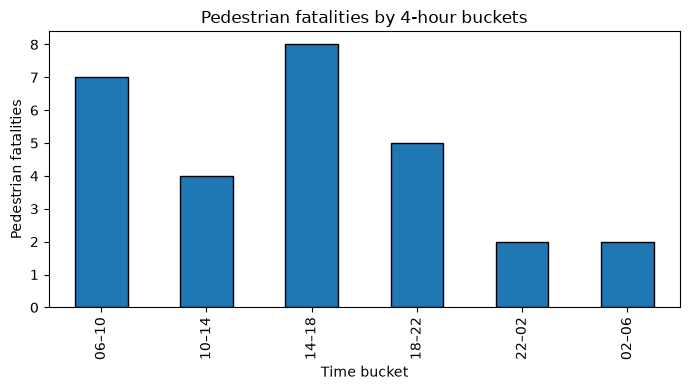

Time bucket
06–10    7
10–14    4
14–18    8
18–22    5
22–02    2
02–06    2
Name: count, dtype: int64

In [116]:
# Pedestrian fatalities only
ped = df[df['Pedestrian'].astype(str).str.upper().str.startswith('Y')].copy()

# Parse 24h time -> hour
ped['Hour'] = pd.to_datetime(ped['Time'], format='%H:%M', errors='coerce').dt.hour
ped = ped.dropna(subset=['Hour'])

# 4-hour buckets anchored at 06:00: 06–10, 10–14, 14–18, 18–22, 22–02, 02–06
labels = ['06–10','10–14','14–18','18–22','22–02','02–06']
bucket_idx = ((ped['Hour'].astype(int) - 6) % 24) // 4
ped['Time bucket'] = bucket_idx.map(dict(enumerate(labels)))

# Counts (ordered) and plot
counts = ped['Time bucket'].value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(7,4))
counts.plot(kind='bar', edgecolor='black')
plt.ylabel('Pedestrian fatalities')
plt.title('Pedestrian fatalities by 4-hour buckets')
plt.tight_layout()
plt.show()

counts

**Statistical significance: fatality rate before vs. after October 2025**

In [117]:
from scipy import stats
import numpy as np

# Compare the fatality rate before vs. after the October 2025 post.
# Treated as two Poisson processes with different exposure (time) windows;
# tested with an exact binomial test conditional on the total count (n1+n2),
# which is the standard exact test for comparing two Poisson rates.
cutoff = pd.Timestamp('2025-10-04')
start = df['Date'].min()
end = df['Date'].max()

baseline = df[df['Date'] < cutoff]
recent = df[df['Date'] >= cutoff]

n1 = int(baseline['Deaths'].sum())
n2 = int(recent['Deaths'].sum())

days_per_month = 30.4375
t1 = (cutoff - start).days / days_per_month
t2 = (end - cutoff).days / days_per_month

rate1 = n1 / t1
rate2 = n2 / t2

print(f"Baseline: {start.date()} to {cutoff.date()} ({t1:.1f} months) -> {n1} fatalities, {rate1:.2f}/month")
print(f"Recent:   {cutoff.date()} to {end.date()} ({t2:.1f} months) -> {n2} fatalities, {rate2:.2f}/month")

# Exact test: under H0 (equal rates), n2 ~ Binomial(n1+n2, p) where p = t2/(t1+t2)
n = n1 + n2
p0 = t2 / (t1 + t2)
result = stats.binomtest(n2, n, p0, alternative='two-sided')

print(f"\nExpected fatalities in recent period under equal-rate null: {n*p0:.1f}")
print(f"Exact binomial test p-value: {result.pvalue:.3f}")

# Incidence rate ratio (recent / baseline) with 95% CI (normal approx on log scale)
irr = rate2 / rate1
se_log_irr = np.sqrt(1/n1 + 1/n2)
ci_lo = np.exp(np.log(irr) - 1.96 * se_log_irr)
ci_hi = np.exp(np.log(irr) + 1.96 * se_log_irr)
print(f"\nRate ratio (recent / baseline): {irr:.2f}  (95% CI: {ci_lo:.2f} - {ci_hi:.2f})")

if result.pvalue < 0.05:
    print("=> Statistically significant difference at α=0.05")
else:
    print("=> Not statistically significant at α=0.05 -- the observed difference could plausibly be due to chance given the current sample size")

Baseline: 2023-01-14 to 2025-10-04 (32.7 months) -> 74 fatalities, 2.27/month
Recent:   2025-10-04 to 2026-08-16 (10.4 months) -> 16 fatalities, 1.54/month

Expected fatalities in recent period under equal-rate null: 21.7
Exact binomial test p-value: 0.176

Rate ratio (recent / baseline): 0.68  (95% CI: 0.40 - 1.17)
=> Not statistically significant at α=0.05 -- the observed difference could plausibly be due to chance given the current sample size
